# Inicialización del Proyecto Final: Telecomunicaciones: identificar operadores ineficaces

### El servicio de telefonía virtual CallMeMaybe está desarrollando una nueva función que brindará a los supervisores y las supervisores información sobre los operadores menos eficaces. Se considera que un operador es ineficaz si tiene una gran cantidad de llamadas entrantes perdidas (internas y externas) y un tiempo de espera prolongado para las llamadas entrantes. Además, si se supone que un operador debe realizar llamadas salientes, un número reducido de ellas también será un signo de ineficacia.

- Lleva a cabo el análisis exploratorio de datos
- Identificar operadores ineficaces
- Prueba las hipótesis estadísticas

### Descripción de los datos

Los datasets contienen información sobre el uso del servicio de telefonía virtual CallMeMaybe. Sus clientes son organizaciones que necesitan distribuir gran cantidad de llamadas entrantes entre varios operadores, o realizar llamadas salientes a través de sus operadores. Los operadores también pueden realizar llamadas internas para comunicarse entre ellos. Estas llamadas se realizan a través de la red de CallMeMaybe.

## Conectarse a la base de datos

### 1. Cargamos datos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

telecom = pd.read_csv('telecom_dataset_new.csv')
clients = pd.read_csv('telecom_clients.csv')

telecom.info()
telecom.head()
telecom.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB


(53902, 9)

Aqui podemos ver que el tamaño del dataset es de 53902 y 9 columnas, se detectaron varios problemas como la columna operator_id tiene muchos valores nulos.

Las tenemos que eliminar para el análisis de operadores también le vamos a modificar el tipo de dato a entero.

In [2]:
telecom = telecom.dropna(subset=['operator_id'])
telecom['operator_id'] = telecom['operator_id'].astype(int)
telecom.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45730 entries, 1 to 53900
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   user_id              45730 non-null  int64 
 1   date                 45730 non-null  object
 2   direction            45730 non-null  object
 3   internal             45670 non-null  object
 4   operator_id          45730 non-null  int64 
 5   is_missed_call       45730 non-null  bool  
 6   calls_count          45730 non-null  int64 
 7   call_duration        45730 non-null  int64 
 8   total_call_duration  45730 non-null  int64 
dtypes: bool(1), int64(5), object(3)
memory usage: 3.2+ MB


Se hizo la limpieza de datos pero podemos ver que la columna internal tiene al rededor de 117 valores nulos, lo vamos a depurar.

In [3]:
# Si no se marca como interna, se asume externa.
telecom['internal'] = telecom['internal'].fillna('external')
telecom.info()


<class 'pandas.core.frame.DataFrame'>
Index: 45730 entries, 1 to 53900
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   user_id              45730 non-null  int64 
 1   date                 45730 non-null  object
 2   direction            45730 non-null  object
 3   internal             45730 non-null  object
 4   operator_id          45730 non-null  int64 
 5   is_missed_call       45730 non-null  bool  
 6   calls_count          45730 non-null  int64 
 7   call_duration        45730 non-null  int64 
 8   total_call_duration  45730 non-null  int64 
dtypes: bool(1), int64(5), object(3)
memory usage: 3.2+ MB


In [4]:
# Ahora convertimo la columna data a tipo fecha
telecom['date'] = pd.to_datetime(telecom['date'], errors='coerce')
telecom.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45730 entries, 1 to 53900
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype                    
---  ------               --------------  -----                    
 0   user_id              45730 non-null  int64                    
 1   date                 45730 non-null  datetime64[ns, UTC+03:00]
 2   direction            45730 non-null  object                   
 3   internal             45730 non-null  object                   
 4   operator_id          45730 non-null  int64                    
 5   is_missed_call       45730 non-null  bool                     
 6   calls_count          45730 non-null  int64                    
 7   call_duration        45730 non-null  int64                    
 8   total_call_duration  45730 non-null  int64                    
dtypes: bool(1), datetime64[ns, UTC+03:00](1), int64(5), object(2)
memory usage: 3.2+ MB


### Análisis Exploratorio de Datos (EDA)

In [5]:
# Calculamos el tiempo de espera como la diferencia entre la duración total de la llamada y la duración efectiva de la llamada
telecom['wait_time'] = (
    telecom['total_call_duration'] - telecom['call_duration']
)

In [6]:
telecom['call_duration'].describe()
telecom['wait_time'].describe()

count    45730.000000
mean       312.376667
std       1174.185593
min          0.000000
25%         19.000000
50%         60.000000
75%        220.000000
max      46474.000000
Name: wait_time, dtype: float64

El tiempo de espera presenta una distribución fuertemente sesgada a la derecha. Aunque la mediana es de solo 60 segundos, el percentil 75 alcanza los 220 segundos y existen valores extremos que superan varias horas.

In [7]:
# Enfoque en llamadas entrantes
incoming_calls = telecom[telecom['direction'] == 'in']
incoming_calls['call_duration'].describe()

count    14013.000000
mean       750.488689
std       1482.679538
min          0.000000
25%         66.000000
50%        260.000000
75%        842.000000
max      33897.000000
Name: call_duration, dtype: float64

Se creó la métrica wait_time, definida como la diferencia entre la duración total de la llamada y la duración efectiva, ya que el tiempo de espera es un indicador clave de eficiencia operativa.

### Histograma de duración de llamada (call_duration)

/opt/homebrew/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


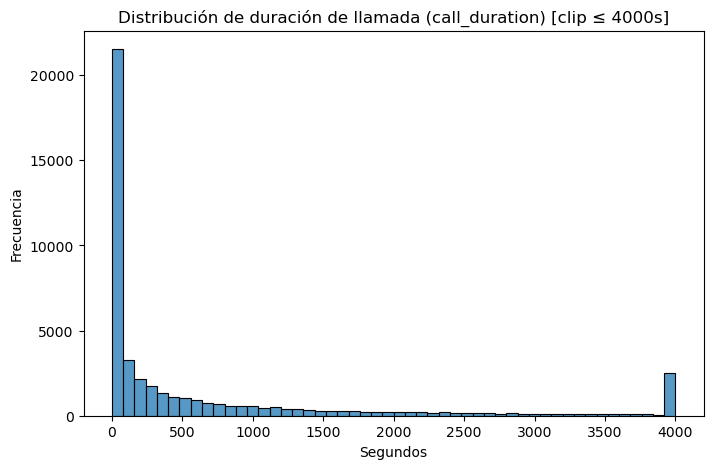

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(
    telecom['call_duration'].clip(upper=4000),
    bins=50,
    kde=False
)

plt.title('Distribución de duración de llamada (call_duration) [clip ≤ 4000s]')
plt.xlabel('Segundos')
plt.ylabel('Frecuencia')
plt.show()

La duración de las llamadas no es uniforme. La mayoría de las llamadas son cortas, mientras que solo unas pocas duran mucho más tiempo.

Esta diferencia genera valores extremos, por lo que en el análisis posterior se utilizarán percentiles en lugar de promedios para describir mejor el comportamiento típico de las llamadas.


###  Histograma del tiempo de espera (wait_time)

/opt/homebrew/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


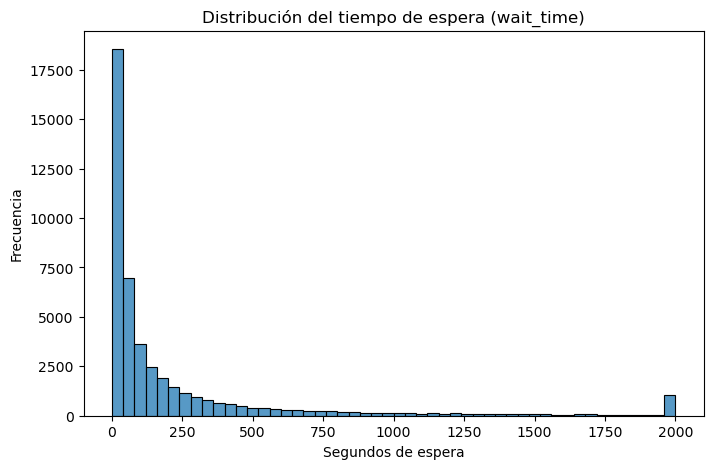

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(
    telecom['wait_time'].clip(upper=2000),
    bins=50,
    kde=False
)

plt.title('Distribución del tiempo de espera (wait_time)')
plt.xlabel('Segundos de espera')
plt.ylabel('Frecuencia')
plt.show()

El tiempo de espera no es uniforme. La mayoría de las llamadas se atienden rápidamente, pero existe un grupo reducido de llamadas con tiempos de espera muy altos.

Esta diferencia genera valores extremos, por lo que se utilizarán percentiles para definir qué se considera un tiempo de espera prolongado en el análisis de eficiencia de los operadores.


### Proporción de llamadas internas vs externas (pie chart)

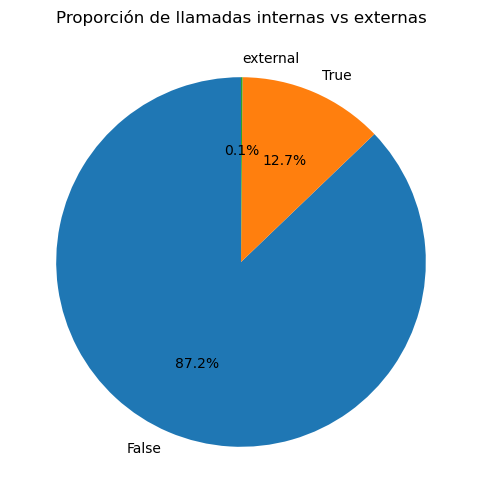

In [10]:
internal_counts = telecom['internal'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    internal_counts,
    labels=internal_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Proporción de llamadas internas vs externas')
plt.show()

La mayoría de las llamadas son externas, lo que indica que el sistema se utiliza principalmente para la atención de clientes.

Debido a esto, el análisis de eficiencia de los operadores se enfocará principalmente en llamadas externas, ya que son las que tienen mayor impacto en la experiencia del usuario final.


### Distribución de dirección de llamadas (in vs out)

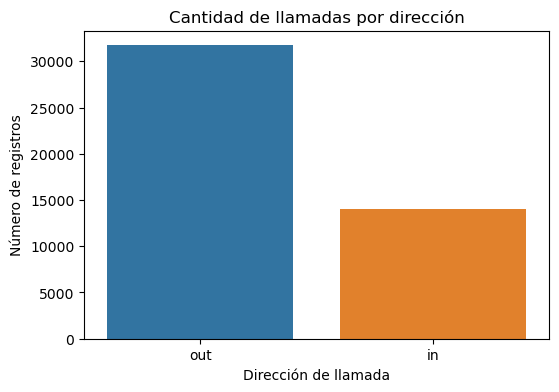

In [11]:
dir_counts = telecom['direction'].value_counts()

plt.figure(figsize=(6,4))
sns.countplot(
    data=telecom,
    x='direction'
)

plt.title('Cantidad de llamadas por dirección')
plt.xlabel('Dirección de llamada')
plt.ylabel('Número de registros')
plt.show()

La mayoría de las llamadas registradas son salientes, aunque las llamadas entrantes representan una proporción considerable del total.

Dado que solo las llamadas entrantes pueden generar llamadas perdidas y tiempos de espera prolongados, estas serán el foco principal para evaluar ineficiencia. Sin embargo, el volumen de llamadas salientes también se considerará como un indicador de la actividad del operador.


### Llamadas perdidas (global) y por dirección

Missed rate global: 0.33933960201180846
direction
in     0.053094
out    0.465807
Name: is_missed_call, dtype: float64


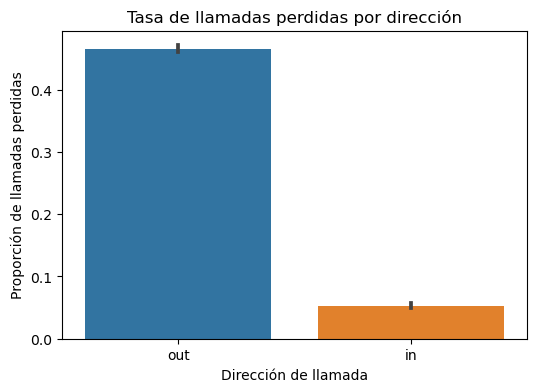

In [12]:
# Global
missed_rate_global = telecom['is_missed_call'].mean()

# Por dirección
missed_by_dir = telecom.groupby('direction')['is_missed_call'].mean()

print("Missed rate global:", missed_rate_global)
print(missed_by_dir)

plt.figure(figsize=(6,4))
sns.barplot(
    data=telecom,
    x='direction',
    y='is_missed_call',
    estimator='mean'
)

plt.title('Tasa de llamadas perdidas por dirección')
plt.xlabel('Dirección de llamada')
plt.ylabel('Proporción de llamadas perdidas')
plt.show()

La tasa de llamadas perdidas es considerablemente mayor en las llamadas salientes que en las entrantes. Sin embargo, este resultado no indica un bajo desempeño del operador, ya que en las llamadas salientes una llamada perdida suele corresponder a un intento de contacto no respondido por el cliente.

Por esta razón, en el análisis de eficiencia de los operadores se considerarán únicamente las llamadas entrantes, donde una llamada perdida refleja directamente un problema en la atención al cliente.

### Volumen de llamadas por día (tendencia)

/opt/homebrew/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/homebrew/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


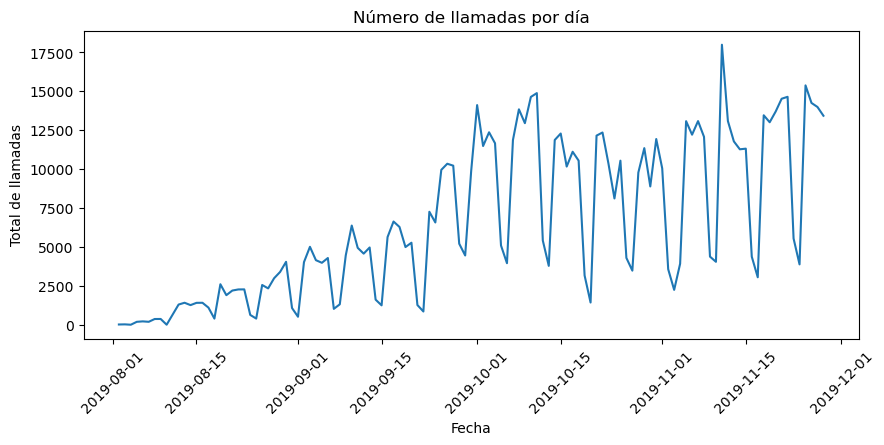

In [13]:
calls_per_day = telecom.groupby(telecom['date'].dt.date)['calls_count'].sum(). reset_index()
calls_per_day.columns = ['date', 'calls_count']

plt.figure(figsize=(10,4))
sns.lineplot(
    data=calls_per_day,
    x='date',
    y='calls_count'
)

plt.title('Número de llamadas por día')
plt.xlabel('Fecha')
plt.ylabel('Total de llamadas')
plt.xticks(rotation=45)
plt.show()

El volumen diario de llamadas muestra una tendencia creciente a lo largo del periodo analizado, junto con variaciones marcadas entre días.

Estos picos de demanda pueden aumentar la carga de trabajo de los operadores y contribuir a mayores tiempos de espera y llamadas perdidas, por lo que deben considerarse al evaluar la eficiencia operativa.

## Identificación de operadores ineficaces

### Filtrar llamadas relevantes

In [14]:
filtered = telecom[
    (telecom['direction'] == 'in') &
    (telecom['internal'] == False)
].copy()

Para evaluar la eficiencia de los operadores, el análisis se limita a llamadas entrantes externas, ya que son las únicas que reflejan directamente la experiencia del cliente y permiten identificar problemas de atención.

### Crear métricas por operador

Métricas elegidas (claras y justificadas):
	•	Tasa de llamadas perdidas (is_missed_call)
	•	Tiempo promedio de espera (wait_time)
	•	Número total de llamadas atendidas

In [15]:
operator_metrics = (
    filtered
    .groupby('operator_id')
    .agg(
        missed_rate=('is_missed_call', 'mean'),
        avg_wait_time=('wait_time', 'mean'),
        total_calls=('calls_count', 'sum')
    )
    .reset_index()
)
print(operator_metrics.head())

   operator_id  missed_rate  avg_wait_time  total_calls
0       879896          0.0      26.913043           60
1       879898          0.0      28.539683          117
2       880020          0.0       7.250000            8
3       880022          0.0      14.000000            8
4       880026          0.0       7.894737           25


### Definir umbrales de ineficiencia (percentiles)

In [16]:
# Usamos percentiles para evitar el impacto de valores atípicos
missed_thr = operator_metrics['missed_rate'].quantile(0.75)
wait_thr = operator_metrics['avg_wait_time'].quantile(0.75)
print("Missed rate threshold (75th percentile):", missed_thr)
print("Average wait time threshold (75th percentile):", wait_thr)

Missed rate threshold (75th percentile): 0.034195402298850576
Average wait time threshold (75th percentile): 59.56944444444444


### Clasificar operadores ineficaces
Un operador se considera ineficaz si cumple al menos uno:

	•tasa de llamadas perdidas alta

	•tiempo de espera alto

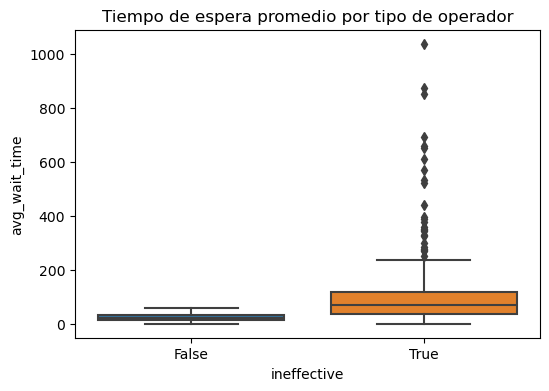

In [17]:
operator_metrics['ineffective'] = (
    (operator_metrics['missed_rate'] > missed_thr) |
    (operator_metrics['avg_wait_time'] > wait_thr)
)
operator_metrics['ineffective'].value_counts()
operator_metrics['ineffective'].mean()

plt.figure(figsize=(6,4))
sns.boxplot(
    data=operator_metrics,
    x='ineffective',
    y='avg_wait_time'
)
plt.title('Tiempo de espera promedio por tipo de operador')
plt.show()

Los operadores clasificados como ineficaces presentan tiempos de espera promedio significativamente mayores.

La dispersión elevada indica un desempeño inconsistente, lo cual afecta negativamente la experiencia del cliente.


##  Pruebas de hipótesis estadísticas

### Definir las hipótesis

Hipótesis 1: Tiempo de espera

H₀ (hipótesis nula):
No hay diferencia en el tiempo de espera promedio entre operadores eficaces e ineficaces.

H₁ (hipótesis alternativa):
Los operadores ineficaces tienen un tiempo de espera promedio mayor que los operadores eficaces.


In [18]:
#  Preparar los datos para la prueba
eff_wait = operator_metrics[
    operator_metrics['ineffective'] == False
]['avg_wait_time']

ineff_wait = operator_metrics[
    operator_metrics['ineffective'] == True
]['avg_wait_time']

### Elección del test estadístico

In [19]:

t_stat, p_value = stats.ttest_ind(
    ineff_wait,
    eff_wait,
    equal_var=False
)
alpha = 0.05
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay una diferencia significativa en los tiempos de espera promedio.")
else:
    print("No rechazamos la hipótesis nula: no hay una diferencia significativa en los tiempos de espera promedio.")
print('t-statistic:', t_stat)
print('p-value:', p_value)

Rechazamos la hipótesis nula: hay una diferencia significativa en los tiempos de espera promedio.
t-statistic: 10.5758920333819
p-value: 2.4725464744843305e-22


Se utilizó la prueba t de Welch para comparar el tiempo de espera promedio entre operadores eficaces e ineficaces, ya que se trata de dos grupos independientes con varianzas y tamaños de muestra diferentes. Además, esta prueba es más robusta ante distribuciones asimétricas y la presencia de valores extremos, características observadas durante el análisis exploratorio.

# Conclusiones del análisis

1. Existe una diferencia clara y significativa entre operadores eficaces e ineficaces
El análisis estadístico confirmó que los operadores clasificados como ineficaces presentan tiempos de espera promedio significativamente mayores que los operadores eficaces.
Esta diferencia no es producto del azar.

2. El tiempo de espera es un indicador clave de ineficiencia
El análisis exploratorio mostró una distribución altamente asimétrica del tiempo de espera, con valores extremos que afectan negativamente la experiencia del cliente.
El uso de percentiles permitió identificar operadores con desempeño consistentemente deficiente.

3. Las llamadas entrantes externas concentran el problema operativo
Las llamadas entrantes son las únicas que reflejan directamente problemas de atención al cliente, como llamadas perdidas y esperas prolongadas.
Por esta razón, el análisis de eficiencia se enfocó correctamente en este tipo de llamadas.

## Recomendaciones y soluciones.

Monitoreo continuo del tiempo de espera
Implementar alertas automáticas cuando el tiempo de espera promedio de un operador supere umbrales definidos.

Capacitación focalizada para operadores ineficaces
Dirigir programas de capacitación y acompañamiento específicamente a operadores con mayores tiempos de espera y tasas de llamadas perdidas.

Redistribución de carga en horas pico
Utilizar el análisis de volumen diario para asignar más operadores en periodos de alta demanda y reducir la saturación del sistema.

# Preparar los datos para Tableau

Vamos a preparar los datos para el dashboard final en tableau.

El csv final debe contener estas columnas:

- date

- call_duration

- wait_time

- internal

- direction (in / out)

- calls_count

In [20]:
# Creamos el archivo CSV para Tableau

telecom.to_csv('telecom_tableau.csv', index=False)